In [3]:
import numpy as np
import matplotlib.pyplot as plt
a = 1
t = 1
V = 0
k = 4

def H_func_shi(a ,kx ,t ,k ,V):   
    H_matrix = np.zeros((2*k, 2*k), dtype=complex)
    for i in range(0,2*k,2):
        if i == 0:
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = t*(1+np.exp(-1j*1.5*a*kx))
            H_matrix[i+1, i] = t*(1+np.exp(+1j*1.5*a*kx))
            H_matrix[i+1, i+1] = V 
            H_matrix[i+1, i+2] = t
        elif i == 2*k-2:
            H_matrix[i, i-1] =  t
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = t*(1+np.exp(-1j*1.5*a*kx))
            H_matrix[i+1, i] = t*(1+np.exp(+1j*1.5*a*kx))
            H_matrix[i+1, i+1] = V 
        else:  
            H_matrix[i, i] = V   
            H_matrix[i, i+1] = t*(1+np.exp(-1j*1.5*a*kx))
            H_matrix[i+1, i] = t*(1+np.exp(+1j*1.5*a*kx))
            H_matrix[i+1, i+1] = V
            H_matrix[i, i-1] =  t
            H_matrix[i+1, i+2] = t
    return H_matrix




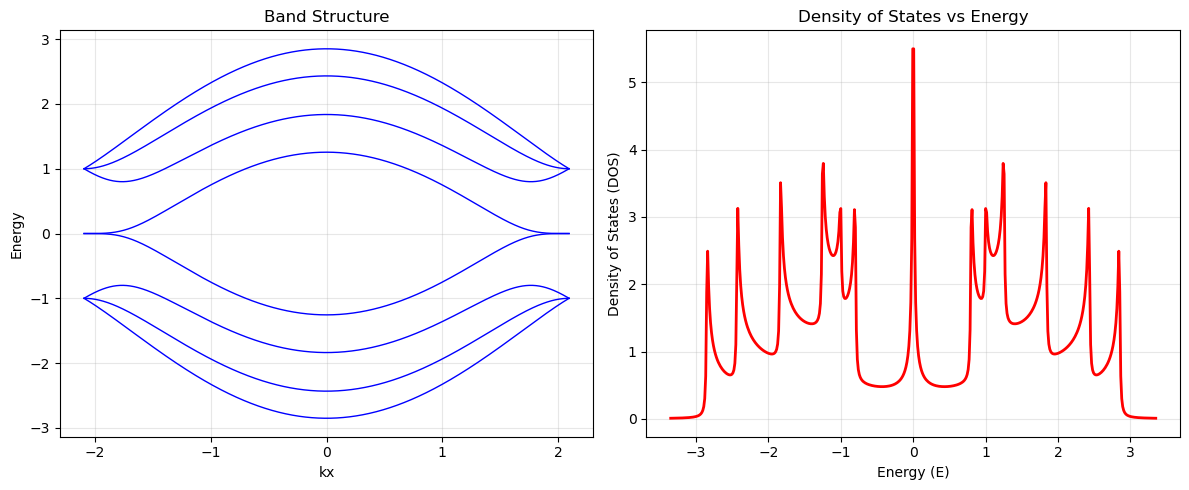

能量范围: -3.351 到 3.351
态密度最大值: 5.498
态密度最小值: 0.008


In [4]:
# kx点设置
kx_set = np.linspace(-np.pi/(1.5*a), np.pi/(1.5*a), 1000)

# 计算能带结构
eigenvalues_set = [[] for _ in range(2*k)]
eigenvectors_set = [[] for _ in range(2*k)]

for kx in kx_set:
    H_matrix = H_func_shi(a, kx, t, k, V)
    eigenvalues, eigenvectors = np.linalg.eig(H_matrix)
    
    idx = np.argsort(eigenvalues.real)
    eigenvalues_sorted = eigenvalues[idx]
    eigenvectors_sorted = eigenvectors[:, idx]
    
    for j in range(2*k):
        eigenvalues_set[j].append(eigenvalues_sorted[j].real)
        eigenvectors_set[j].append(eigenvectors_sorted[:, j])

eigenvalues_set = np.array(eigenvalues_set)
eigenvectors_set = np.array(eigenvectors_set)

# 格林函数方法计算态密度
def calculate_dos(eigenvalues_set, eigenvectors_set, E_values, eta=10**(-5)):
    """
    使用格林函数方法计算态密度
    
    参数:
    eigenvalues_set: 能带本征值, 形状 (能带数, kx点数)
    eigenvectors_set: 本征向量, 形状 (能带数, kx点数, 系统尺寸)
    E_values: 能量范围
    eta: 小虚部，用于数值稳定性
    
    返回:
    dos: 态密度随能量的变化
    """
    N_kx = len(kx_set)
    N_bands = eigenvalues_set.shape[0]
    dos = np.zeros_like(E_values, dtype=float)
    
    for i, E in enumerate(E_values):
        total_trace = 0.0
        
        for kx_idx in range(N_kx):
            # 构建格林函数 G(E) = (E + iη - H)^(-1)
            # 使用谱表示: G(E) = Σ_n |ψ_n⟩⟨ψ_n| / (E + iη - E_n)
            G = np.zeros((2*k, 2*k), dtype=complex)
            
            for band_idx in range(N_bands):
                E_n = eigenvalues_set[band_idx, kx_idx]
                psi = eigenvectors_set[band_idx, kx_idx].reshape(-1, 1)  # 列向量
                psi_dagger = psi.conj().T  # 行向量
                
                # 添加谱表示项
                denominator = E + 1j*eta - E_n
                G += (psi @ psi_dagger) / denominator
            
            # 计算 -Im(Tr(G))/π，这是态密度
            total_trace += -np.imag(np.trace(G)) / np.pi
        
        # 对kx点求平均
        dos[i] = total_trace / N_kx
    
    return dos

# 定义能量范围
E_min = np.min(eigenvalues_set) - 0.5
E_max = np.max(eigenvalues_set) + 0.5
E_values = np.linspace(E_min, E_max, 500)

# 计算态密度
dos = calculate_dos(eigenvalues_set, eigenvectors_set, E_values, eta=0.01)

# 绘制能带结构和态密度
plt.figure(figsize=(12, 5))

# 子图1: 能带结构
plt.subplot(1, 2, 1)
for i in range(2*k):
    plt.plot(kx_set, eigenvalues_set[i], 'b-', linewidth=1)
plt.xlabel('kx')
plt.ylabel('Energy')
plt.title('Band Structure')
plt.grid(True, alpha=0.3)

# 子图2: 态密度
plt.subplot(1, 2, 2)
plt.plot(E_values, dos, 'r-', linewidth=2)
plt.xlabel('Energy (E)')
plt.ylabel('Density of States (DOS)')
plt.title('Density of States vs Energy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 输出一些统计信息
print(f"能量范围: {E_min:.3f} 到 {E_max:.3f}")
print(f"态密度最大值: {np.max(dos):.3f}")
print(f"态密度最小值: {np.min(dos):.3f}")